In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%%capture
!pip3 install -q imgaug albumentations==1.3.1 timm einops ftfy regex lmdb fvcore
!pip install -q "numpy<2" --force-reinstall

In [ ]:
import numpy, torch, torchvision
# print("numpy:", numpy.__version__)
# print("torch:", torch.__version__)
# print("torchvision:", torchvision.__version__)
print("CUDA:", torch.cuda.is_available())

CUDA: True


In [ ]:
%%capture
%cd /content/drive/MyDrive/Capstone_Hripsime/Frameworks/DeepfakeBench
!pip install jedi
!python -m pip install -U pip setuptools wheel
!pip install -r requirements.txt
!pip install -e .

In [ ]:
%%capture
%cd "/content/drive/MyDrive/Capstone_Hripsime/Frameworks/ForensicHub"
!head -n -1 requirements.txt > requirements_no_flash.txt
!pip install -r requirements_no_flash.txt

In [ ]:
import os, glob, json, random

TRAIN_DIR = "/content/drive/MyDrive/Capstone_Hripsime/Database/RDDC_Dataset/Datasets/training_data"
VAL_DIR   = "/content/drive/MyDrive/Capstone_Hripsime/Database/RDDC_Dataset/Datasets/validation_data"
TEST_DIR  = "/content/drive/MyDrive/Capstone_Hripsime/Database/RDDC_Dataset/Datasets/publictest_data"

VAL_REF   = "/content/drive/MyDrive/Capstone_Hripsime/Database/RDDC_Dataset/RDDC_References/validation_reference/reference.txt"
TEST_REF  = "/content/drive/MyDrive/Capstone_Hripsime/Database/RDDC_Dataset/RDDC_References/publictest_reference/reference.txt"

STAGING = "/content/DiffusionForensics_Recons"
os.makedirs(STAGING, exist_ok=True)

IMG_EXTS = (".png", ".jpg", ".jpeg", ".webp", ".bmp", ".tif", ".tiff")

# ═══════════════════════════════════════════════════
# TRAINING — training_data_final
# ═══════════════════════════════════════════════════
train_items = []
for ext in IMG_EXTS:
    for p in glob.glob(os.path.join(TRAIN_DIR, f"*{ext}")):
        name = os.path.basename(p).lower()
        if "_real" in name:
            train_items.append({"path": p, "label": 0})
        elif "_fake" in name:
            train_items.append({"path": p, "label": 1})

random.seed(42)
random.shuffle(train_items)

n_real = sum(1 for x in train_items if x["label"] == 0)
n_fake = sum(1 for x in train_items if x["label"] == 1)
print(f"TRAIN: {len(train_items)} images  (real={n_real}, fake={n_fake})")

# ═══════════════════════════════════════════════════
# VALIDATION — validation_data_final + reference.txt
# ═══════════════════════════════════════════════════
with open(VAL_REF) as f:
    val_labels = [int(line.strip()) for line in f if line.strip()]

val_images = sorted(glob.glob(os.path.join(VAL_DIR, "*.*")))
val_images = [p for p in val_images if os.path.splitext(p)[1].lower() in IMG_EXTS]

assert len(val_images) == len(val_labels), \
    f"Mismatch: {len(val_images)} images vs {len(val_labels)} labels"

val_items = [{"path": p, "label": l} for p, l in zip(val_images, val_labels)]

n_real = sum(1 for x in val_items if x["label"] == 0)
n_fake = sum(1 for x in val_items if x["label"] == 1)
print(f"VAL:   {len(val_items)} images  (real={n_real}, fake={n_fake})")

# ═══════════════════════════════════════════════════
# TEST — publictest_data_final + reference.txt
# ═══════════════════════════════════════════════════
with open(TEST_REF) as f:
    test_labels = [int(line.strip()) for line in f if line.strip()]

test_images = sorted(glob.glob(os.path.join(TEST_DIR, "*.*")))
test_images = [p for p in test_images if os.path.splitext(p)[1].lower() in IMG_EXTS]

assert len(test_images) == len(test_labels), \
    f"Mismatch: {len(test_images)} images vs {len(test_labels)} labels"

test_items = [{"path": p, "label": l} for p, l in zip(test_images, test_labels)]

n_real = sum(1 for x in test_items if x["label"] == 0)
n_fake = sum(1 for x in test_items if x["label"] == 1)
print(f"TEST:  {len(test_items)} images  (real={n_real}, fake={n_fake})")

# ═══════════════════════════════════════════════════
# SAVE JSONs
# ═══════════════════════════════════════════════════
for name, data in [("train", train_items), ("val", val_items), ("test", test_items)]:
    out = os.path.join(STAGING, f"{name}.json")
    with open(out, "w") as f:
        json.dump(data, f)
    print(f"\n✓ {name}.json → {len(data)} items → {out}")


TRAIN: 1000 images  (real=500, fake=500)
VAL:   100 images  (real=50, fake=50)
TEST:  1000 images  (real=500, fake=500)

✓ train.json → 1000 items → /content/DiffusionForensics_Recons/train.json

✓ val.json → 100 items → /content/DiffusionForensics_Recons/val.json

✓ test.json → 1000 items → /content/DiffusionForensics_Recons/test.json


In [ ]:
# import shutil
# from pathlib import Path

# CKPT_DIR = Path("/content/drive/MyDrive/Capstone_Hripsime/Frameworks/ForensicHub/log/effort_test")

# if CKPT_DIR.exists():
#     shutil.rmtree(CKPT_DIR)
#     print("🧹 Old checkpoints deleted")

# CKPT_DIR.mkdir(parents=True, exist_ok=True)
# print("✅ Fresh checkpoint directory created:", CKPT_DIR)

✅ Fresh checkpoint directory created: /content/drive/MyDrive/Capstone_Hripsime/Frameworks/ForensicHub/log/effort_test


In [ ]:
# %cd /content/drive/MyDrive/Capstone_Hripsime/Frameworks/ForensicHub

# !PYTHONPATH=/content/drive/MyDrive/Capstone_Hripsime/Frameworks:$PWD \
# MASTER_ADDR=127.0.0.1 MASTER_PORT=29602 \
# python -m ForensicHub.training_scripts.test \
# --config "ForensicHub/statics/crossdataset_image/effort_test.yaml"

/content/drive/.shortcut-targets-by-id/1dhyo0l8QyhlSMCpS1lnpG93K1z7h6d4K/Capstone_Hripsime/Frameworks/ForensicHub
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
2.10.0+cu128
Current Torch version: 2.10
/usr/local/lib/python3.12/dist-packages/timm/optim/optim_factory.py:7: FutureWarning: Importing from timm.optim.optim_factory is deprecated, please import via timm.optim
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.optim", FutureWarning)
2026-04-30 07:13:04.221026: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the app

In [ ]:
import os
import json
import glob
import numpy as np
import torch
from PIL import Image
import sys

BASE = "/content/drive/MyDrive/Capstone_Hripsime/Frameworks"

sys.path.insert(0, BASE)
sys.path.insert(0, f"{BASE}/ForensicHub")
sys.path.insert(0, f"{BASE}/DeepfakeBench")
sys.path.insert(0, f"{BASE}/IMDLBenCo")

# Important: registers DeepfakeBench detectors such as EffortDetector
import ForensicHub.tasks.deepfake

from ForensicHub.registry import MODELS, build_from_registry


# =========================
# PATHS
# =========================
CHECKPOINT_DIR = f"{BASE}/ForensicHub/log/effort_train"
LOG_PATH = os.path.join(CHECKPOINT_DIR, "log.txt")

TEST_JSON = "/content/DiffusionForensics_Recons/test.json"
OUT_RESULTS = "/content/DiffusionForensics_Recons/effort_test_inference_results.json"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
THRESHOLD = 0.5
IMAGE_SIZE = 224


# =========================
# FIND BEST CHECKPOINT BY VAL AUC
# =========================
def find_best_checkpoint_by_auc(checkpoint_dir, log_path):
    entries = []

    with open(log_path, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            try:
                e = json.loads(line)
            except json.JSONDecodeError:
                continue

            if "epoch" in e and "test_image-level AUC" in e:
                entries.append(e)

    if not entries:
        raise RuntimeError(f"No valid AUC entries found in log: {log_path}")

    # If the log contains multiple restarted runs, use only the last run
    runs = []
    current_run = []
    prev_epoch = -1

    for e in entries:
        ep = int(e["epoch"])

        if ep <= prev_epoch and current_run:
            runs.append(current_run)
            current_run = []

        current_run.append(e)
        prev_epoch = ep

    if current_run:
        runs.append(current_run)

    last_run = runs[-1]

    best_entry = max(last_run, key=lambda x: float(x["test_image-level AUC"]))
    best_epoch = int(best_entry["epoch"])
    best_auc = float(best_entry["test_image-level AUC"])
    best_f1 = float(best_entry.get("test_image-level F1", np.nan))

    # Prefer exact checkpoint-{best_epoch}.pth
    exact_ckpt = os.path.join(checkpoint_dir, f"checkpoint-{best_epoch}.pth")

    if os.path.exists(exact_ckpt):
        return exact_ckpt, best_epoch, best_auc, best_f1

    # Fallback: choose nearest available checkpoint <= best_epoch
    available = sorted(
        glob.glob(os.path.join(checkpoint_dir, "checkpoint-*.pth")),
        key=lambda p: int(
            os.path.basename(p)
            .replace("checkpoint-", "")
            .replace(".pth", "")
        )
    )

    if not available:
        raise FileNotFoundError(f"No checkpoint-*.pth files found in {checkpoint_dir}")

    candidates = [
        p for p in available
        if int(os.path.basename(p).replace("checkpoint-", "").replace(".pth", "")) <= best_epoch
    ]

    chosen = candidates[-1] if candidates else available[-1]

    print(
        f"Exact checkpoint for best epoch not found: checkpoint-{best_epoch}.pth\n"
        f"Using fallback checkpoint: {os.path.basename(chosen)}"
    )

    return chosen, best_epoch, best_auc, best_f1


CHECKPOINT_PATH, BEST_EPOCH, BEST_AUC, BEST_F1 = find_best_checkpoint_by_auc(
    CHECKPOINT_DIR,
    LOG_PATH
)

print("Best checkpoint selected from validation log:")
print(f"  Best epoch: {BEST_EPOCH}")
print(f"  Best val AUC: {BEST_AUC:.6f}")
print(f"  Val F1 at that epoch: {BEST_F1:.6f}")
print(f"  Checkpoint: {CHECKPOINT_PATH}")


# =========================
# PREPROCESS — Effort / CLIP
# =========================
def preprocess_pil(img, image_size=224):
    img = img.resize((image_size, image_size))
    arr = np.asarray(img).astype("float32") / 255.0
    arr = arr.transpose(2, 0, 1)

    # CLIP normalization for Effort
    mean = np.array([0.48145466, 0.4578275, 0.40821073], dtype=np.float32)[:, None, None]
    std  = np.array([0.26862954, 0.26130258, 0.27577711], dtype=np.float32)[:, None, None]
    arr = (arr - mean) / std

    return torch.tensor(arr, dtype=torch.float32)


# =========================
# BUILD MODEL — Effort
# =========================
model_args = {
    "name": "EffortDetector",
    "init_config": {
        "yaml_config_path": f"{BASE}/DeepfakeBench/DeepfakeBench/training/config/config/detector/effort.yaml"
    }
}

model = build_from_registry(MODELS, model_args)

checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
state_dict = checkpoint["model"] if "model" in checkpoint else checkpoint

missing, unexpected = model.load_state_dict(state_dict, strict=False)

print(f"\nLoaded checkpoint: {CHECKPOINT_PATH}")
print(f"Missing keys: {len(missing)}")
print(f"Unexpected keys: {len(unexpected)}")

if len(missing) > 0:
    print("First missing keys:", missing[:10])

if len(unexpected) > 0:
    print("First unexpected keys:", unexpected[:10])

model.to(DEVICE)
model.eval()


# =========================
# LOAD TEST ITEMS
# =========================
with open(TEST_JSON, "r") as f:
    test_items = json.load(f)

results = []
skipped = []


# =========================
# INFERENCE
# =========================
with torch.no_grad():
    for i, item in enumerate(test_items):
        path = item["path"]
        true_label = int(item["label"])

        try:
            img = Image.open(path).convert("RGB")
            x = preprocess_pil(img, image_size=IMAGE_SIZE).unsqueeze(0).to(DEVICE)

            input_dict = {
                "image": x,
                "label": torch.tensor([true_label], dtype=torch.long).to(DEVICE),
                "mask": torch.ones(1, 1, IMAGE_SIZE, IMAGE_SIZE, device=DEVICE),
            }

            out_dict = model(**input_dict)

            score = float(out_dict["pred_label"].view(-1)[0].item())
            pred = 1 if score >= THRESHOLD else 0

            results.append({
                "path": path,
                "true_label": true_label,
                "pred": int(pred),
                "score": score,
                "correct": bool(pred == true_label),
                "checkpoint_epoch": BEST_EPOCH,
                "checkpoint_val_auc": BEST_AUC,
                "checkpoint_val_f1": BEST_F1,
            })

        except Exception as e:
            skipped.append({
                "path": path,
                "error": str(e),
            })

        if (i + 1) % 100 == 0:
            print(f"{i+1}/{len(test_items)} processed | ok={len(results)} | skipped={len(skipped)}")

print("\nProcessed:", len(results))
print("Skipped:", len(skipped))

with open(OUT_RESULTS, "w") as f:
    json.dump(results, f, indent=2)

print("Saved:", OUT_RESULTS)

Best checkpoint selected from validation log:
  Best epoch: 17
  Best val AUC: 0.677812
  Val F1 at that epoch: 0.621622
  Checkpoint: /content/drive/MyDrive/Capstone_Hripsime/Frameworks/ForensicHub/log/effort_train/checkpoint-17.pth
[lazy import] Loading 'EffortDetector' from 'DeepfakeBench.training.detectors.effort_detector'
[build_from_registry] Creating model 'EffortDetector' with args: {'yaml_config_path': '/content/drive/MyDrive/Capstone_Hripsime/Frameworks/DeepfakeBench/DeepfakeBench/training/config/config/detector/effort.yaml'}


Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


embeddings.class_embedding: False
embeddings.patch_embedding.weight: False
embeddings.position_embedding.weight: False
pre_layrnorm.weight: False
pre_layrnorm.bias: False
encoder.layers.0.self_attn.k_proj.weight_main: False
encoder.layers.0.self_attn.k_proj.bias: False
encoder.layers.0.self_attn.k_proj.S_residual: True
encoder.layers.0.self_attn.k_proj.U_residual: True
encoder.layers.0.self_attn.k_proj.V_residual: True
encoder.layers.0.self_attn.v_proj.weight_main: False
encoder.layers.0.self_attn.v_proj.bias: False
encoder.layers.0.self_attn.v_proj.S_residual: True
encoder.layers.0.self_attn.v_proj.U_residual: True
encoder.layers.0.self_attn.v_proj.V_residual: True
encoder.layers.0.self_attn.q_proj.weight_main: False
encoder.layers.0.self_attn.q_proj.bias: False
encoder.layers.0.self_attn.q_proj.S_residual: True
encoder.layers.0.self_attn.q_proj.U_residual: True
encoder.layers.0.self_attn.q_proj.V_residual: True
encoder.layers.0.self_attn.out_proj.weight_main: False
encoder.layers.0.s

In [3]:
# ============================================================
# Save recovered Effort baseline artifacts for one-command reproduction
# Fast version: uses exact Effort train log path
# ============================================================

import os
import json
import shutil
from pathlib import Path

SUBMISSION_ROOT = Path(
    "/content/drive/.shortcut-targets-by-id/1dhyo0l8QyhlSMCpS1lnpG93K1z7h6d4K/"
    "Capstone_Hripsime/submission"
)

EFFORT_OUT = SUBMISSION_ROOT / "test_outputs" / "effort"
EFFORT_OUT.mkdir(parents=True, exist_ok=True)

EFFORT_TRAIN_LOG_OUT = SUBMISSION_ROOT / "logs" / "effort_train"
EFFORT_TRAIN_LOG_OUT.mkdir(parents=True, exist_ok=True)

BASE = "/content/drive/MyDrive/Capstone_Hripsime/Frameworks"
CHECKPOINT_DIR = f"{BASE}/ForensicHub/log/effort_train"
LOG_PATH = os.path.join(CHECKPOINT_DIR, "log.txt")

# Recovered Effort public-test confusion matrix
TP = 288
TN = 431
FP = 69
FN = 212

precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
accuracy = (TP + TN) / (TP + TN + FP + FN)

# AUC cannot be reconstructed from TP/TN/FP/FN, so preserve the submitted value.
auc = 0.76

metric_summary = {
    "model": "Effort",
    "artifact_type": "metric_summary_from_preserved_output",
    "note": (
        "The original Effort checkpoint and per-image prediction file were not available. "
        "This artifact preserves the submitted public-test metrics and confusion-matrix counts. "
        "AUC is stored from the submitted/preserved result because AUC cannot be reconstructed "
        "from TP/TN/FP/FN alone."
    ),
    "confusion_matrix": {
        "TP": TP,
        "TN": TN,
        "FP": FP,
        "FN": FN
    },
    "metrics": {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "accuracy": accuracy,
        "auc": auc
    },
    "paper_rounded_metrics": {
        "precision": 0.81,
        "recall": 0.58,
        "f1": 0.67,
        "accuracy": 0.71,
        "auc": 0.76
    }
}

with open(EFFORT_OUT / "metric_summary.json", "w") as f:
    json.dump(metric_summary, f, indent=2)

with open(EFFORT_OUT / "effort_test_summary.json", "w") as f:
    json.dump(metric_summary, f, indent=2)

metadata = {
    "model": "Effort",
    "threshold": 0.5,
    "checkpoint_dir": CHECKPOINT_DIR,
    "log_path": LOG_PATH,
    "has_checkpoint": False,
    "has_per_image_predictions": False,
    "reproduction_mode": "summary_metrics_and_confusion_matrix",
    "warning": (
        "No preds.npy or labels.npy are provided for Effort baseline because the original "
        "checkpoint and per-image predictions were accidentally deleted. The one-command "
        "script should use metric_summary.json for Effort."
    ),
    "metrics_after_recovery": metric_summary["metrics"],
    "confusion_matrix": metric_summary["confusion_matrix"]
}

with open(EFFORT_OUT / "metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

if os.path.exists(LOG_PATH):
    shutil.copy2(LOG_PATH, EFFORT_TRAIN_LOG_OUT / "log.txt")
    print("Copied Effort train log to:", EFFORT_TRAIN_LOG_OUT / "log.txt")
else:
    print("WARNING: Effort train log not found:", LOG_PATH)

print("\nSaved Effort recovered artifacts:")
print(" -", EFFORT_OUT / "metric_summary.json")
print(" -", EFFORT_OUT / "effort_test_summary.json")
print(" -", EFFORT_OUT / "metadata.json")

print("\nRecovered Effort public-test metrics:")
print(f"P:    {precision:.4f}")
print(f"R:    {recall:.4f}")
print(f"F1:   {f1:.4f}")
print(f"Acc:  {accuracy:.4f}")
print(f"AUC:  {auc:.4f}")
print(f"TP={TP}, TN={TN}, FP={FP}, FN={FN}")

Copied Effort train log to: /content/drive/.shortcut-targets-by-id/1dhyo0l8QyhlSMCpS1lnpG93K1z7h6d4K/Capstone_Hripsime/submission/logs/effort_train/log.txt

Saved Effort recovered artifacts:
 - /content/drive/.shortcut-targets-by-id/1dhyo0l8QyhlSMCpS1lnpG93K1z7h6d4K/Capstone_Hripsime/submission/test_outputs/effort/metric_summary.json
 - /content/drive/.shortcut-targets-by-id/1dhyo0l8QyhlSMCpS1lnpG93K1z7h6d4K/Capstone_Hripsime/submission/test_outputs/effort/effort_test_summary.json
 - /content/drive/.shortcut-targets-by-id/1dhyo0l8QyhlSMCpS1lnpG93K1z7h6d4K/Capstone_Hripsime/submission/test_outputs/effort/metadata.json

Recovered Effort public-test metrics:
P:    0.8067
R:    0.5760
F1:   0.6721
Acc:  0.7190
AUC:  0.7600
TP=288, TN=431, FP=69, FN=212


Saved: /content/drive/.shortcut-targets-by-id/1dhyo0l8QyhlSMCpS1lnpG93K1z7h6d4K/Capstone_Hripsime/submission/results/figures/effort_test_confusion_matrix_recovered.jpg


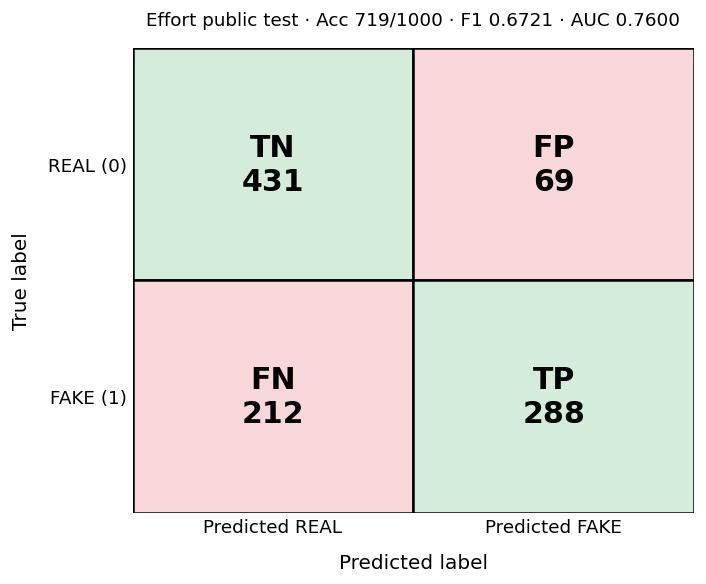

In [4]:
import matplotlib.pyplot as plt
from IPython.display import Image, display

EFFORT_FIG_DIR = SUBMISSION_ROOT / "results" / "figures"
EFFORT_FIG_DIR.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor("white")

cell_labels = [["TN", "FP"], ["FN", "TP"]]
cell_values = [[TN, FP], [FN, TP]]
cell_colors = [
    ["#d4edda", "#f8d7da"],
    ["#f8d7da", "#d4edda"],
]

for i in range(2):
    for j in range(2):
        ax.add_patch(
            plt.Rectangle(
                (j, 1 - i),
                1,
                1,
                facecolor=cell_colors[i][j],
                edgecolor="black",
                linewidth=1.5,
            )
        )
        ax.text(
            j + 0.5,
            1 - i + 0.5,
            f"{cell_labels[i][j]}\n{cell_values[i][j]}",
            ha="center",
            va="center",
            fontsize=18,
            fontweight="bold",
            color="black",
        )

ax.set_xlim(0, 2)
ax.set_ylim(0, 2)
ax.set_xticks([0.5, 1.5])
ax.set_yticks([1.5, 0.5])

ax.set_xticklabels(["Predicted REAL", "Predicted FAKE"], fontsize=11)
ax.set_yticklabels(["REAL (0)", "FAKE (1)"], fontsize=11)

ax.set_xlabel("Predicted label", fontsize=12, labelpad=10)
ax.set_ylabel("True label", fontsize=12, labelpad=10)
ax.tick_params(length=0)

for spine in ax.spines.values():
    spine.set_visible(False)

correct = TP + TN
total = TP + TN + FP + FN

ax.set_title(
    f"Effort public test · Acc {correct}/{total} · F1 {f1:.4f} · AUC {auc:.4f}",
    fontsize=11,
    pad=14,
)

plt.tight_layout()

fig_path = EFFORT_FIG_DIR / "effort_test_confusion_matrix_recovered.jpg"
plt.savefig(fig_path, dpi=120, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.close(fig)

print("Saved:", fig_path)
display(Image(filename=str(fig_path)))

Score appears to be fake probability. Using score directly.
Checkpoint epoch used: 17
Checkpoint val AUC:    0.6778115501519757
Checkpoint val F1:     0.6216216087341309
Score mode used:       score

Test Accuracy: 0.7190
Test F1:       0.6721
Test AUC:      0.7677
Result:        719/1000
AUC direct:    0.7677
AUC inverted:  0.2323
════════════════════════════════════════════
  Confusion Matrix Results
════════════════════════════════════════════
  TP (fake correctly detected) : 288
  TN (real correctly detected) : 431
  FP (real wrongly called fake): 69
  FN (fake wrongly called real): 212
────────────────────────────────────────────
  Precision(fake): 0.8067
  Recall(fake):    0.5760
  Wrong:           281/1000


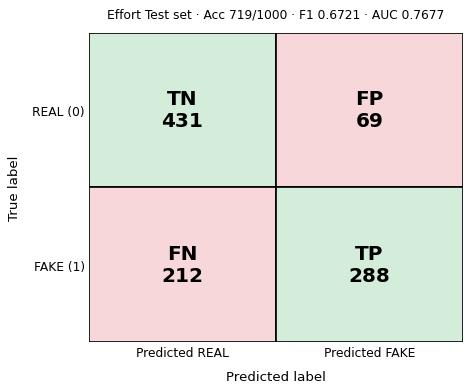

In [ ]:
%matplotlib inline
import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, f1_score, roc_auc_score, accuracy_score
from IPython.display import Image, display

THRESHOLD = 0.5

with open(OUT_RESULTS, "r") as f:
    results = json.load(f)

if len(results) == 0:
    raise RuntimeError("Result file is empty.")

y_true = np.array([int(r["true_label"]) for r in results])
y_score = np.array([float(r["score"]) for r in results])

# Check whether Effort score behaves like fake probability or real probability
auc_direct = roc_auc_score(y_true, y_score)
auc_inverted = roc_auc_score(y_true, 1.0 - y_score)

if auc_inverted > auc_direct:
    print("Score appears reversed. Using 1 - score as fake probability.")
    fake_score = 1.0 - y_score
    score_mode = "1 - score"
else:
    print("Score appears to be fake probability. Using score directly.")
    fake_score = y_score
    score_mode = "score"

y_pred = (fake_score >= THRESHOLD).astype(int)

f1 = f1_score(y_true, y_pred)
auc = roc_auc_score(y_true, fake_score)
acc = accuracy_score(y_true, y_pred)

cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
TN, FP, FN, TP = cm.ravel()

total = TP + TN + FP + FN
correct = TP + TN
wrong = FP + FN

precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0

print(f"Checkpoint epoch used: {results[0].get('checkpoint_epoch', 'unknown')}")
print(f"Checkpoint val AUC:    {results[0].get('checkpoint_val_auc', 'unknown')}")
print(f"Checkpoint val F1:     {results[0].get('checkpoint_val_f1', 'unknown')}")
print(f"Score mode used:       {score_mode}")
print()
print(f"Test Accuracy: {acc:.4f}")
print(f"Test F1:       {f1:.4f}")
print(f"Test AUC:      {auc:.4f}")
print(f"Result:        {correct}/{total}")
print(f"AUC direct:    {auc_direct:.4f}")
print(f"AUC inverted:  {auc_inverted:.4f}")

print(f"{'═'*44}")
print("  Confusion Matrix Results")
print(f"{'═'*44}")
print(f"  TP (fake correctly detected) : {TP}")
print(f"  TN (real correctly detected) : {TN}")
print(f"  FP (real wrongly called fake): {FP}")
print(f"  FN (fake wrongly called real): {FN}")
print(f"{'─'*44}")
print(f"  Precision(fake): {precision:.4f}")
print(f"  Recall(fake):    {recall:.4f}")
print(f"  Wrong:           {wrong}/{total}")

# Styled confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor("white")

cell_labels = [["TN", "FP"], ["FN", "TP"]]
cell_values = [[TN, FP], [FN, TP]]
cell_colors = [
    ["#d4edda", "#f8d7da"],
    ["#f8d7da", "#d4edda"]
]

for i in range(2):
    for j in range(2):
        ax.add_patch(
            plt.Rectangle(
                (j, 1 - i), 1, 1,
                facecolor=cell_colors[i][j],
                edgecolor="black",
                linewidth=1.5
            )
        )
        ax.text(
            j + 0.5,
            1 - i + 0.5,
            f"{cell_labels[i][j]}\n{cell_values[i][j]}",
            ha="center",
            va="center",
            fontsize=18,
            fontweight="bold",
            color="black"
        )

ax.set_xlim(0, 2)
ax.set_ylim(0, 2)
ax.set_xticks([0.5, 1.5])
ax.set_yticks([1.5, 0.5])

ax.set_xticklabels(["Predicted REAL", "Predicted FAKE"], fontsize=11)
ax.set_yticklabels(["REAL (0)", "FAKE (1)"], fontsize=11)

ax.set_xlabel("Predicted label", fontsize=12, labelpad=10)
ax.set_ylabel("True label", fontsize=12, labelpad=10)
ax.tick_params(length=0)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_title(
    f"Effort Test set · Acc {correct}/{total} · F1 {f1:.4f} · AUC {auc:.4f}",
    fontsize=11,
    pad=14
)

plt.tight_layout()
plt.savefig(
    "effort_test_confusion_matrix.jpg",
    dpi=80,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)
plt.close(fig)

display(Image("effort_test_confusion_matrix.jpg"))

Using score directly as fake confidence.
AUC direct: 0.7677

PublicTest: 719/1000 correct (71.9% accuracy)
REAL images: 500  |  FAKE images: 500
Well detected: 719  |  Badly detected: 281
TP=288, TN=431, FP=69, FN=212

REAL accuracy: 86.20%
FAKE accuracy: 57.60%
FAKE precision: 0.8067
FAKE recall:    0.5760
FAKE F1:        0.6721


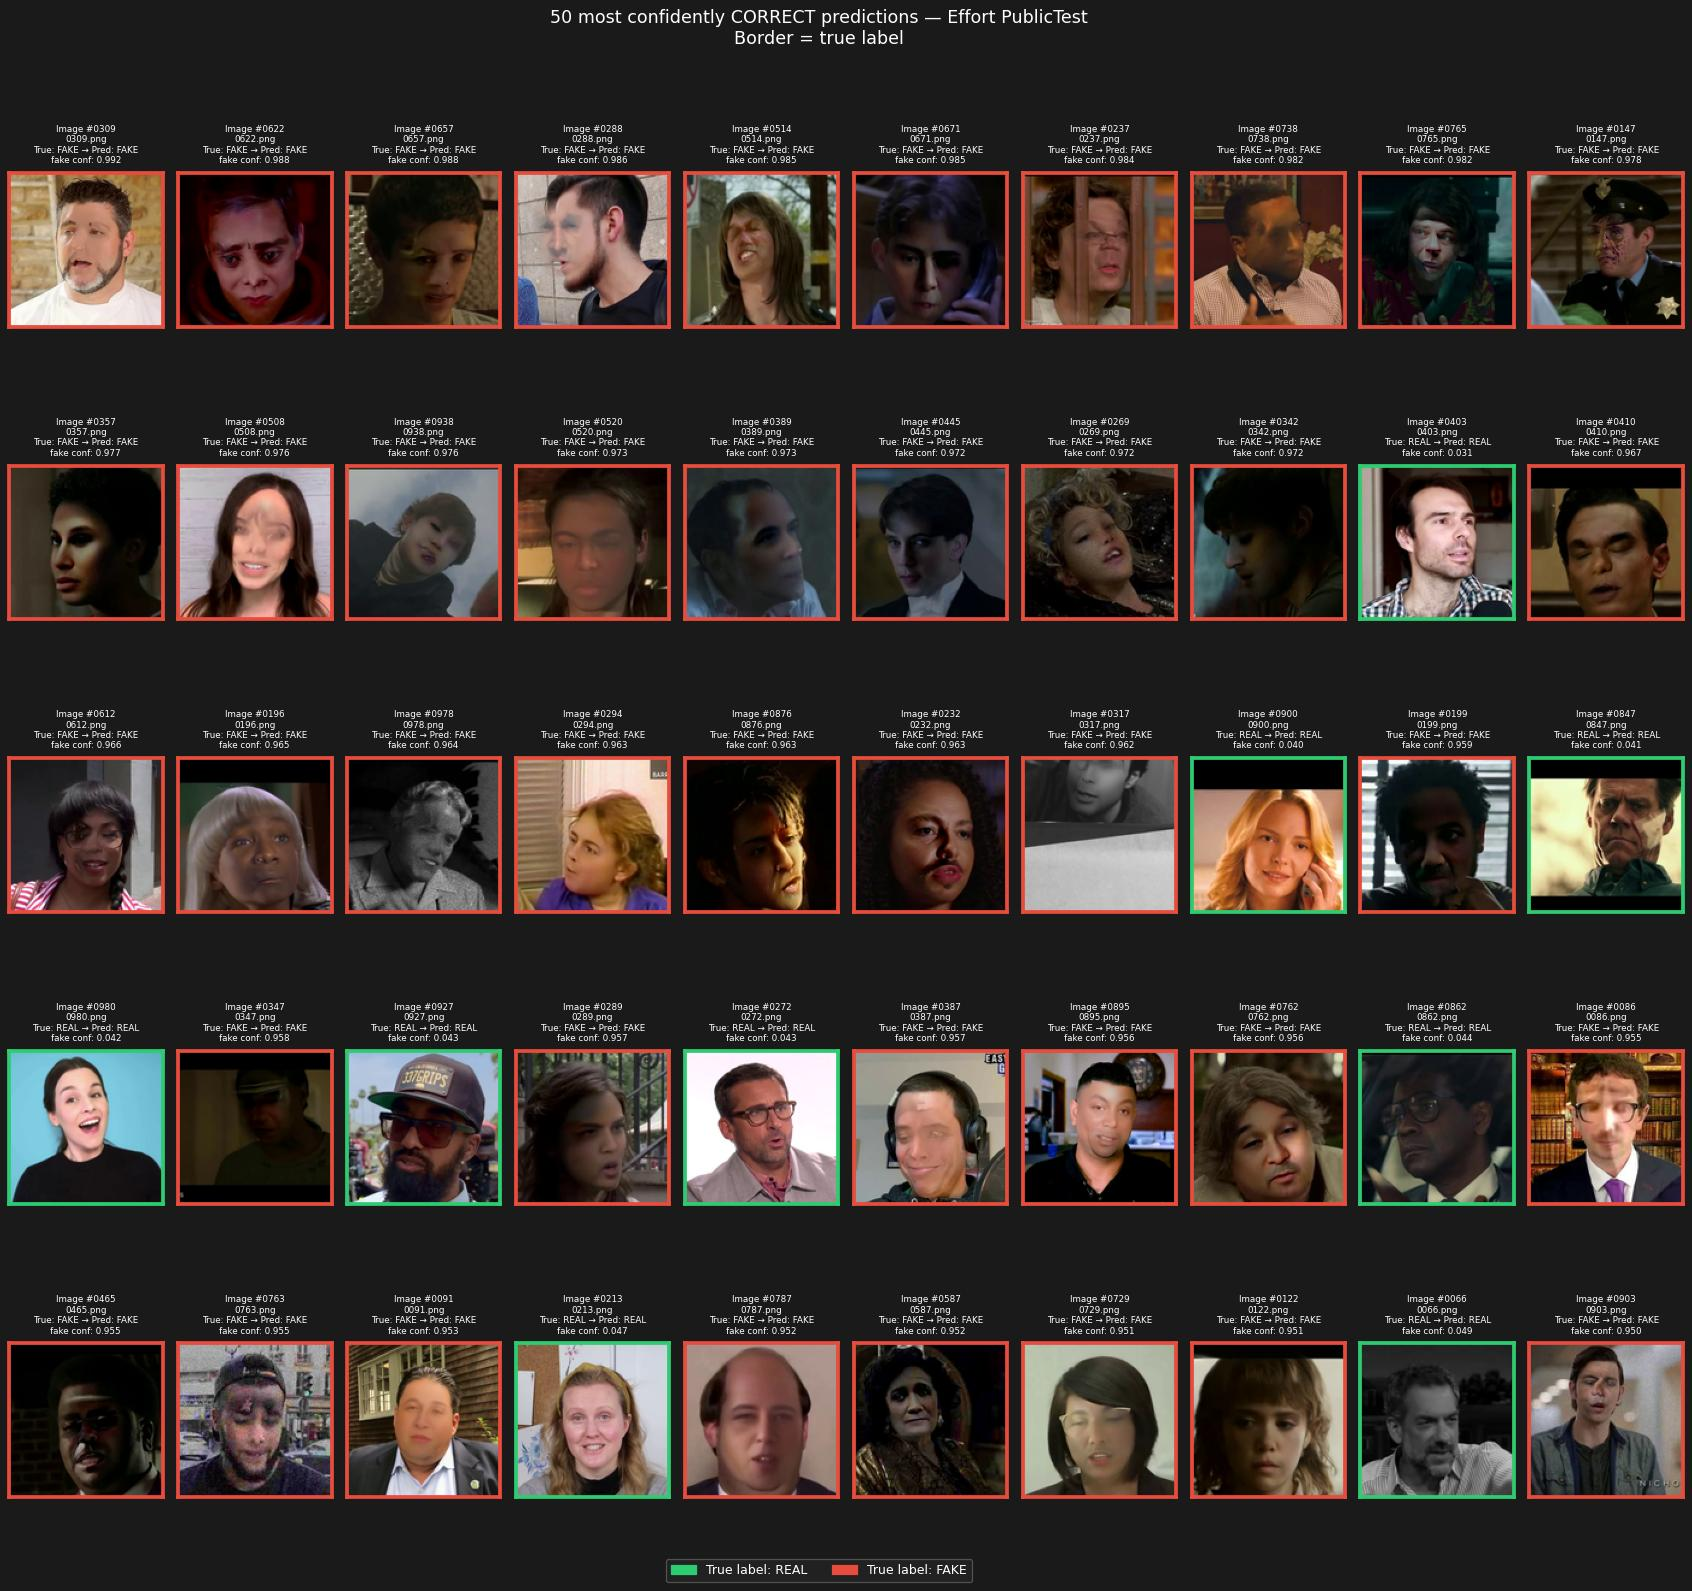

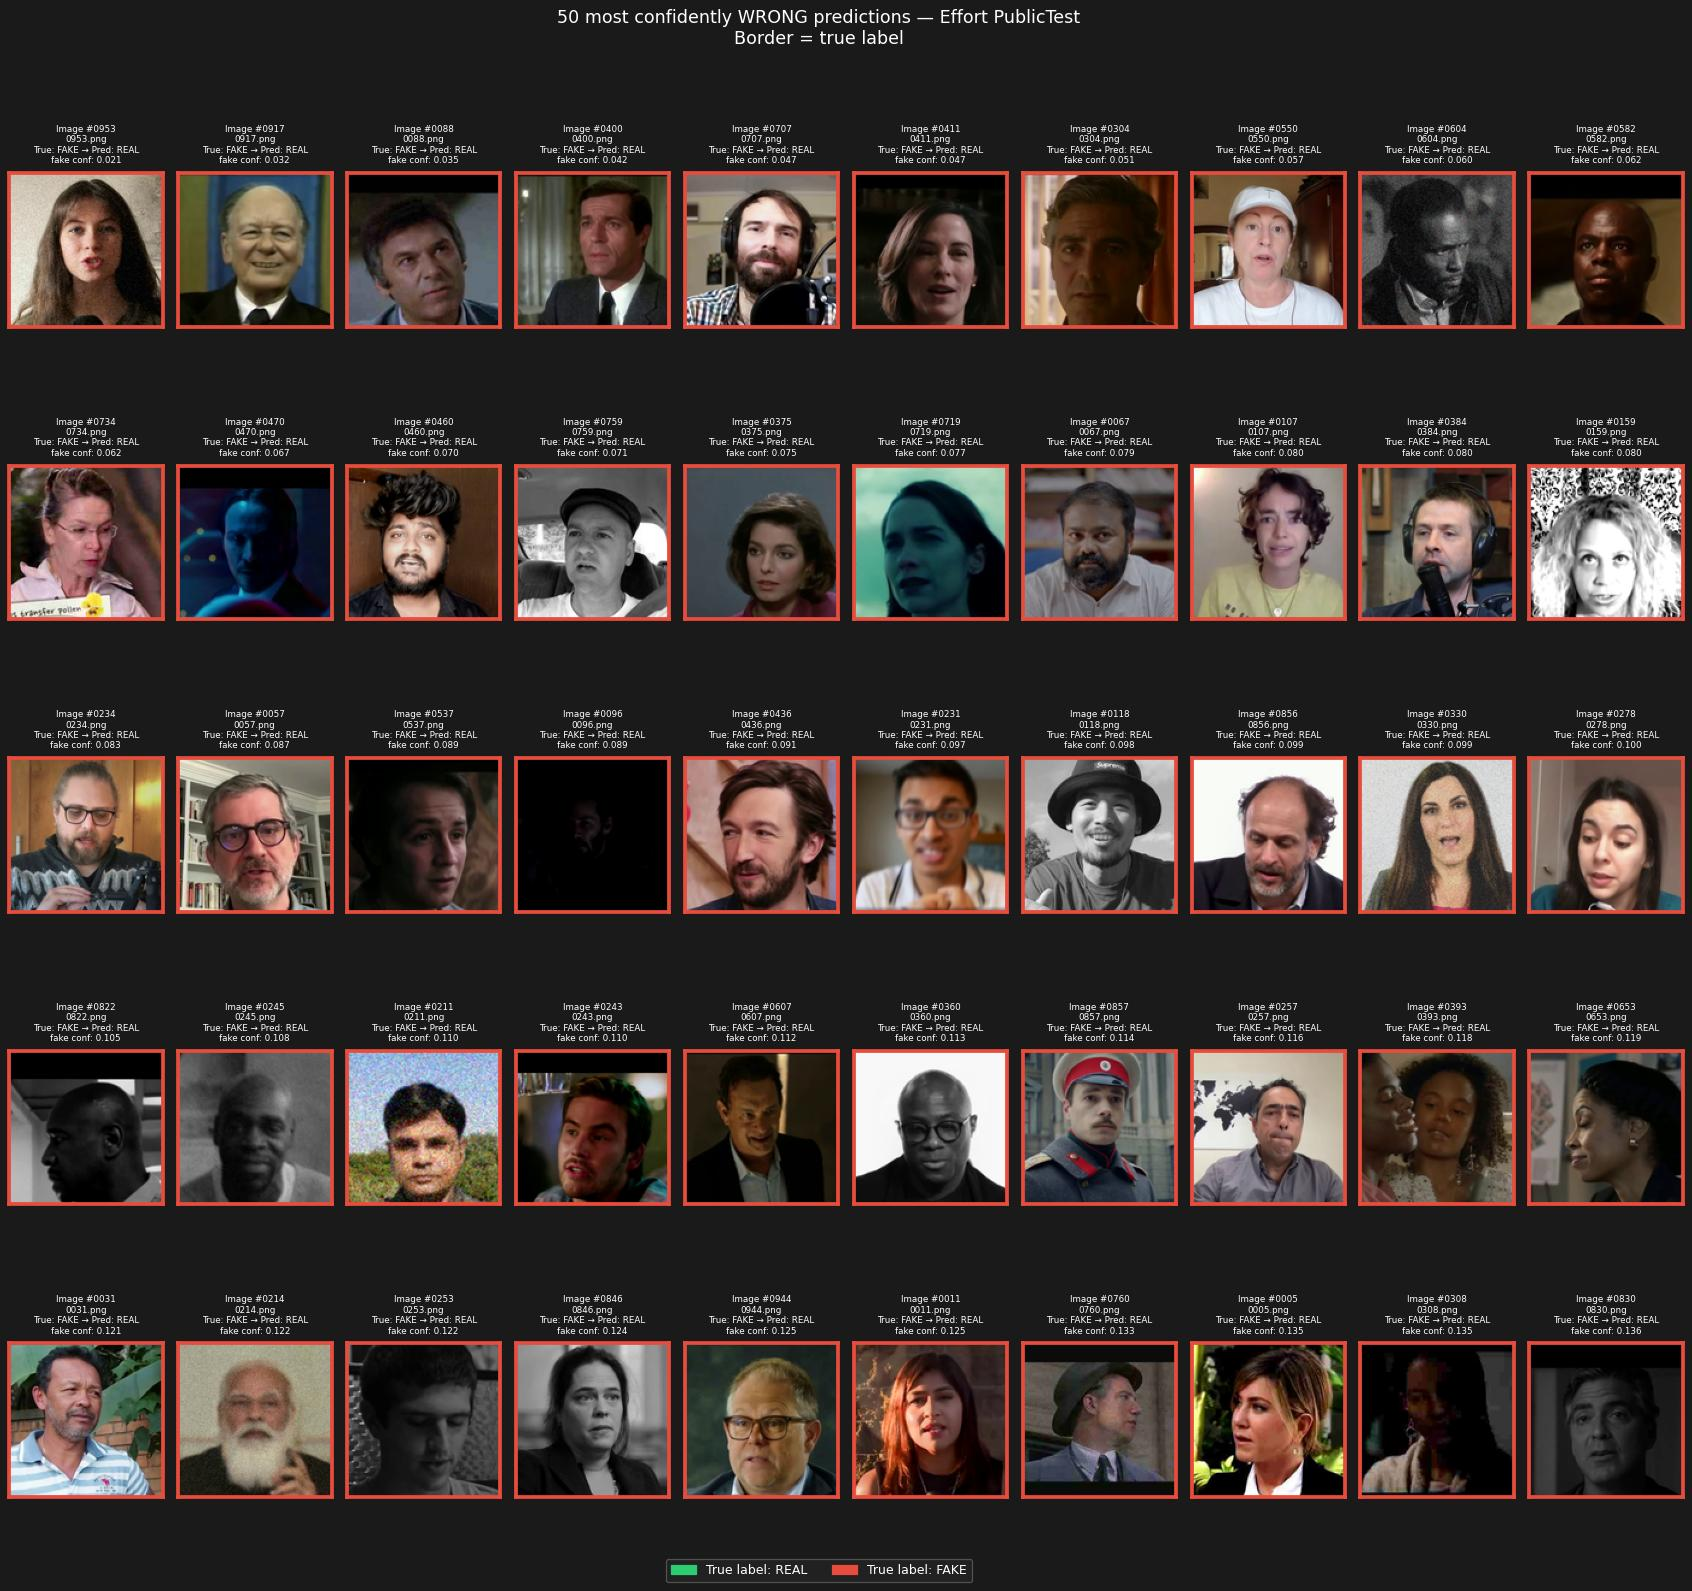

In [ ]:
# ── Badly / Well Detected — PublicTest — Effort, normal score only ──

%matplotlib inline

import os
import re
import json
import numpy as np
from PIL import Image as PILImage
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import Image, display
from sklearn.metrics import roc_auc_score

THRESHOLD = 0.5

with open(OUT_RESULTS, "r") as f:
    results = json.load(f)

if len(results) == 0:
    raise RuntimeError("Test results file is empty.")

# ── Use normal Effort score directly as fake confidence ───────────────────────
y_true = np.array([int(r["true_label"]) for r in results])
raw_score = np.array([float(r["score"]) for r in results])

auc_direct = roc_auc_score(y_true, raw_score)
print("Using score directly as fake confidence.")
print(f"AUC direct: {auc_direct:.4f}")

# ── Rebuild confidence, predictions, and correct/wrong ────────────────────────
for r in results:
    confidence = float(r["score"])

    r["confidence"] = confidence
    r["pred"] = int(confidence >= THRESHOLD)
    r["correct"] = int(r["pred"]) == int(r["true_label"])

total = len(results)
n_correct = sum(r["correct"] for r in results)
accuracy = 100 * n_correct / total

well = [r for r in results if r["correct"]]
badly = [r for r in results if not r["correct"]]

well_sorted = sorted(well, key=lambda x: abs(x["confidence"] - 0.5), reverse=True)
badly_sorted = sorted(badly, key=lambda x: abs(x["confidence"] - 0.5), reverse=True)

well_sample = well_sorted[:50]
badly_sample = badly_sorted[:50]

n_real = sum(int(r["true_label"]) == 0 for r in results)
n_fake = sum(int(r["true_label"]) == 1 for r in results)

tp = sum((int(r["true_label"]) == 1 and int(r["pred"]) == 1) for r in results)
tn = sum((int(r["true_label"]) == 0 and int(r["pred"]) == 0) for r in results)
fp = sum((int(r["true_label"]) == 0 and int(r["pred"]) == 1) for r in results)
fn = sum((int(r["true_label"]) == 1 and int(r["pred"]) == 0) for r in results)

real_acc = 100 * tn / max(1, n_real)
fake_acc = 100 * tp / max(1, n_fake)
precision_fake = tp / max(1, tp + fp)
recall_fake = tp / max(1, tp + fn)
f1_fake = 2 * precision_fake * recall_fake / max(1e-12, precision_fake + recall_fake)

print(f"\nPublicTest: {n_correct}/{total} correct ({accuracy:.1f}% accuracy)")
print(f"REAL images: {n_real}  |  FAKE images: {n_fake}")
print(f"Well detected: {len(well)}  |  Badly detected: {len(badly)}")
print(f"TP={tp}, TN={tn}, FP={fp}, FN={fn}")
print(f"\nREAL accuracy: {real_acc:.2f}%")
print(f"FAKE accuracy: {fake_acc:.2f}%")
print(f"FAKE precision: {precision_fake:.4f}")
print(f"FAKE recall:    {recall_fake:.4f}")
print(f"FAKE F1:        {f1_fake:.4f}")

# ── Helpers ───────────────────────────────────────────────────────────────────
def label_str(l):
    return "REAL" if int(l) == 0 else "FAKE"

def get_image_number(path):
    fname = os.path.basename(path)
    stem = os.path.splitext(fname)[0]

    if stem.isdigit():
        return stem

    m = re.search(r"\d+", stem)
    return m.group(0) if m else "unknown"

def load_thumb(path, size=128):
    img = PILImage.open(path).convert("RGB")
    w, h = img.size
    side = min(w, h)
    img = img.crop((
        (w - side) // 2,
        (h - side) // 2,
        (w + side) // 2,
        (h + side) // 2
    ))
    return img.resize((size, size), PILImage.LANCZOS)

def make_grid(samples, title, filename):
    n = len(samples)
    if n == 0:
        print(f"No samples to plot for {filename}")
        return

    cols = 10
    rows = max(1, (n + cols - 1) // cols)

    fig, axes = plt.subplots(rows, cols, figsize=(24, rows * 3.6))
    fig.patch.set_facecolor("#1a1a1a")

    if rows == 1:
        flat_axes = axes.flatten() if hasattr(axes, "flatten") else [axes]
    else:
        flat_axes = axes.flatten()

    for idx, ax in enumerate(flat_axes):
        if idx >= n:
            ax.axis("off")
            continue

        r = samples[idx]

        try:
            ax.imshow(load_thumb(r["path"]))
        except Exception:
            ax.set_facecolor("#333")
            ax.text(
                0.5, 0.5, "error",
                ha="center", va="center",
                color="white", fontsize=7,
                transform=ax.transAxes
            )

        true_color = "#2ecc71" if int(r["true_label"]) == 0 else "#e74c3c"
        for spine in ax.spines.values():
            spine.set_edgecolor(true_color)
            spine.set_linewidth(3)

        ax.set_xticks([])
        ax.set_yticks([])

        img_num = get_image_number(r["path"])
        fname = os.path.basename(r["path"])

        ax.set_title(
            f"Image #{img_num}\n"
            f"{fname}\n"
            f"True: {label_str(r['true_label'])} → Pred: {label_str(r['pred'])}\n"
            f"fake conf: {r['confidence']:.3f}",
            fontsize=7,
            color="white",
            pad=8
        )

    for ax in flat_axes[n:]:
        ax.axis("off")

    real_p = mpatches.Patch(color="#2ecc71", label="True label: REAL")
    fake_p = mpatches.Patch(color="#e74c3c", label="True label: FAKE")
    fig.legend(
        handles=[real_p, fake_p],
        loc="lower center",
        ncol=2,
        fontsize=10,
        framealpha=0.3,
        facecolor="#333",
        labelcolor="white",
        bbox_to_anchor=(0.5, 0.005)
    )

    fig.suptitle(title, fontsize=14, color="white", fontweight="medium")
    plt.subplots_adjust(hspace=0.85, wspace=0.1, top=0.88, bottom=0.06)

    plt.savefig(
        filename,
        dpi=90,
        bbox_inches="tight",
        facecolor=fig.get_facecolor()
    )
    plt.close(fig)
    display(Image(filename))

# ── Plots ─────────────────────────────────────────────────────────────────────
make_grid(
    well_sample,
    title="50 most confidently CORRECT predictions — Effort PublicTest\n"
          "Border = true label",
    filename="effort_well_detected_test.jpg"
)

make_grid(
    badly_sample,
    title="50 most confidently WRONG predictions — Effort PublicTest\n"
          "Border = true label",
    filename="effort_badly_detected_test.jpg"
)

Using score directly as fake confidence.
AUC direct: 0.7677

Correct predictions: 719
Wrong predictions:   281
Showing correct top50 grouped: 50
Showing wrong top50 grouped:   50


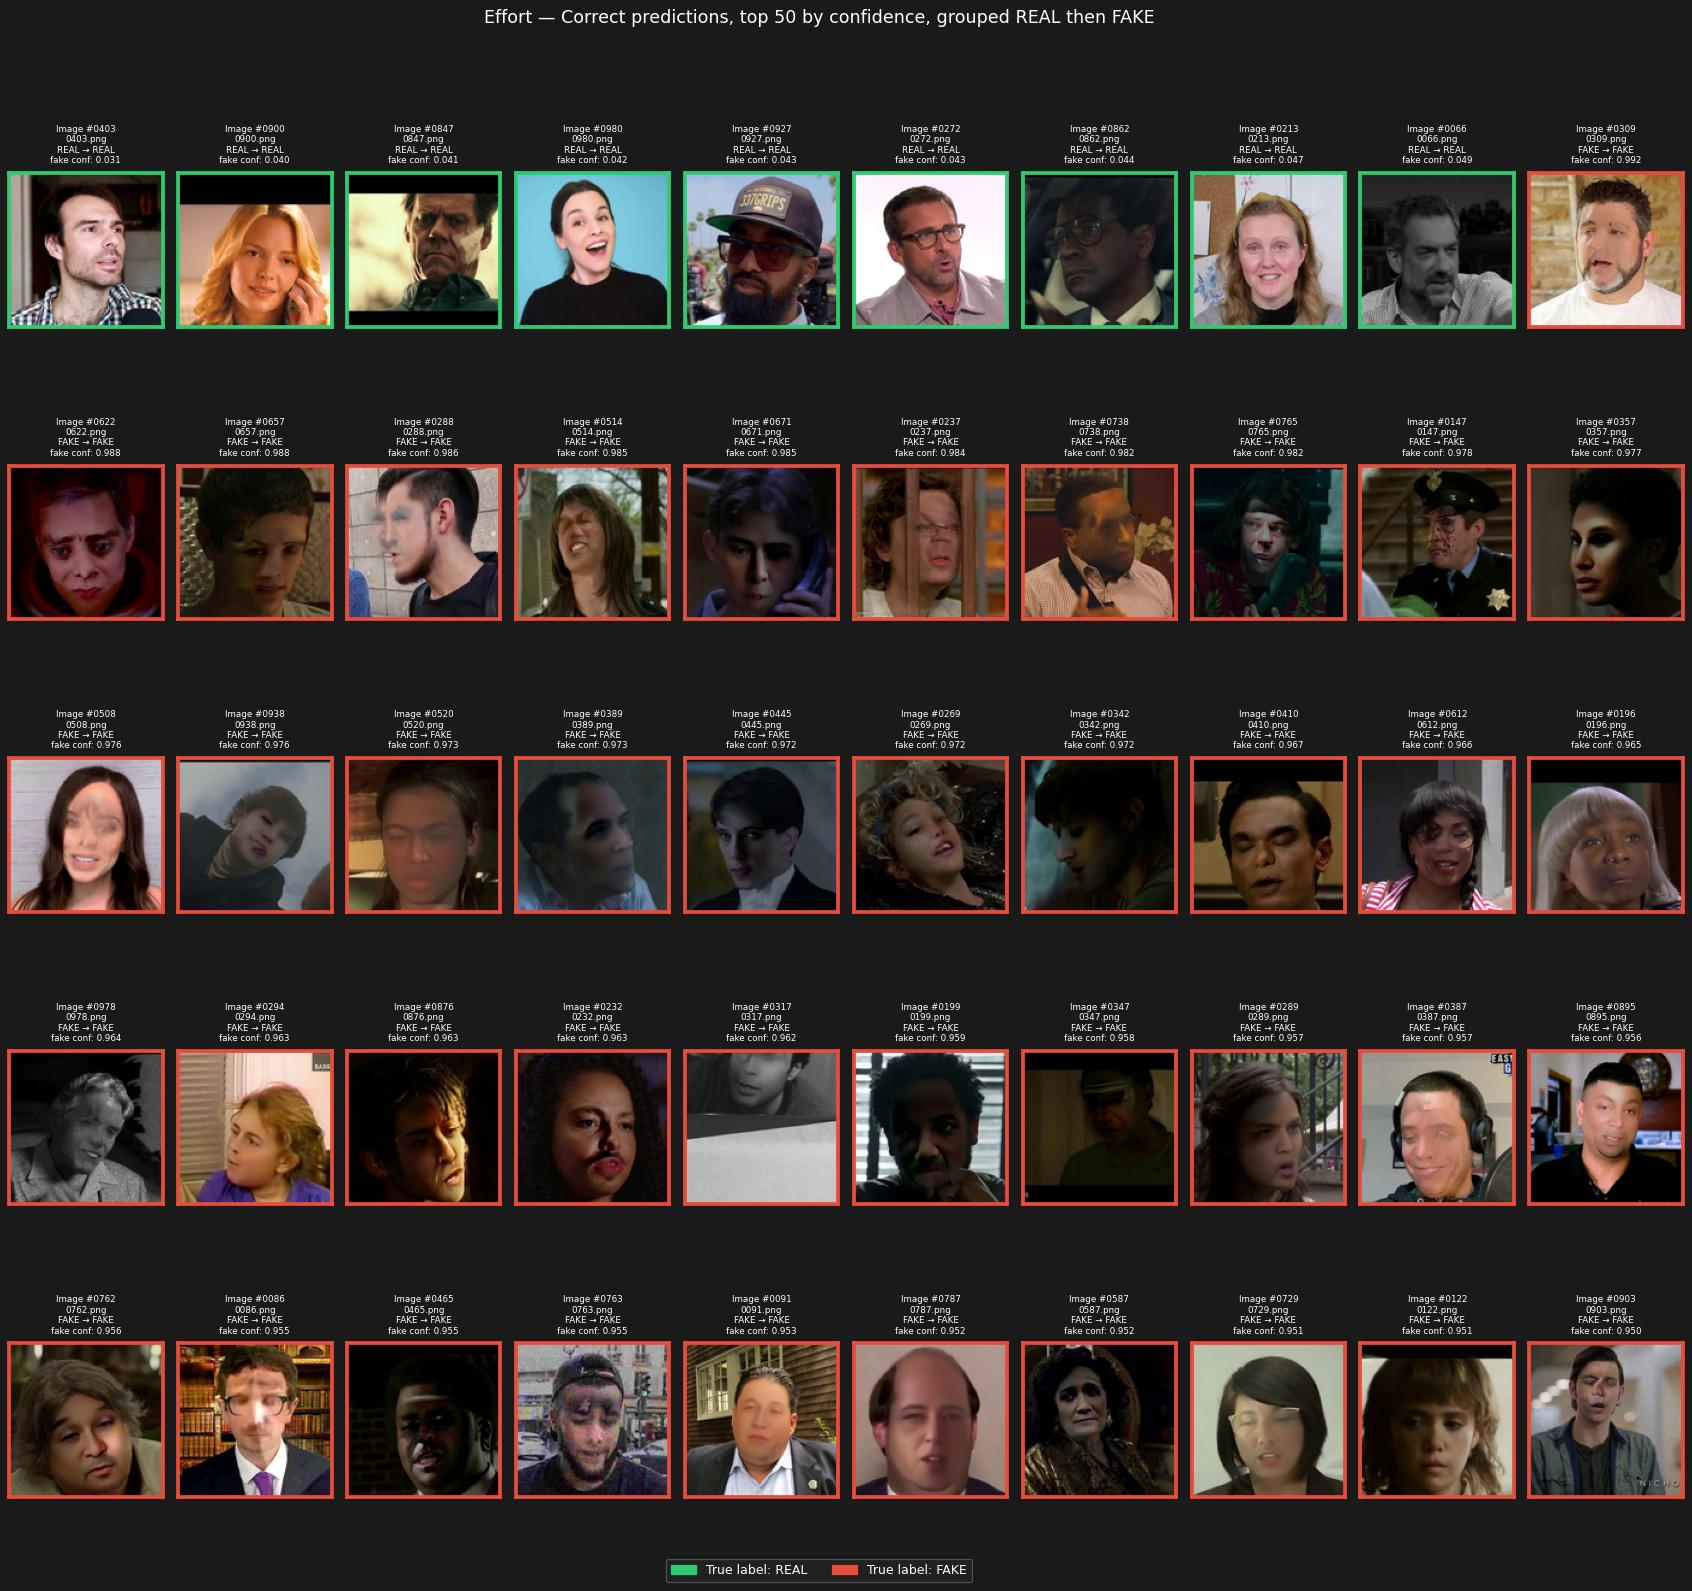

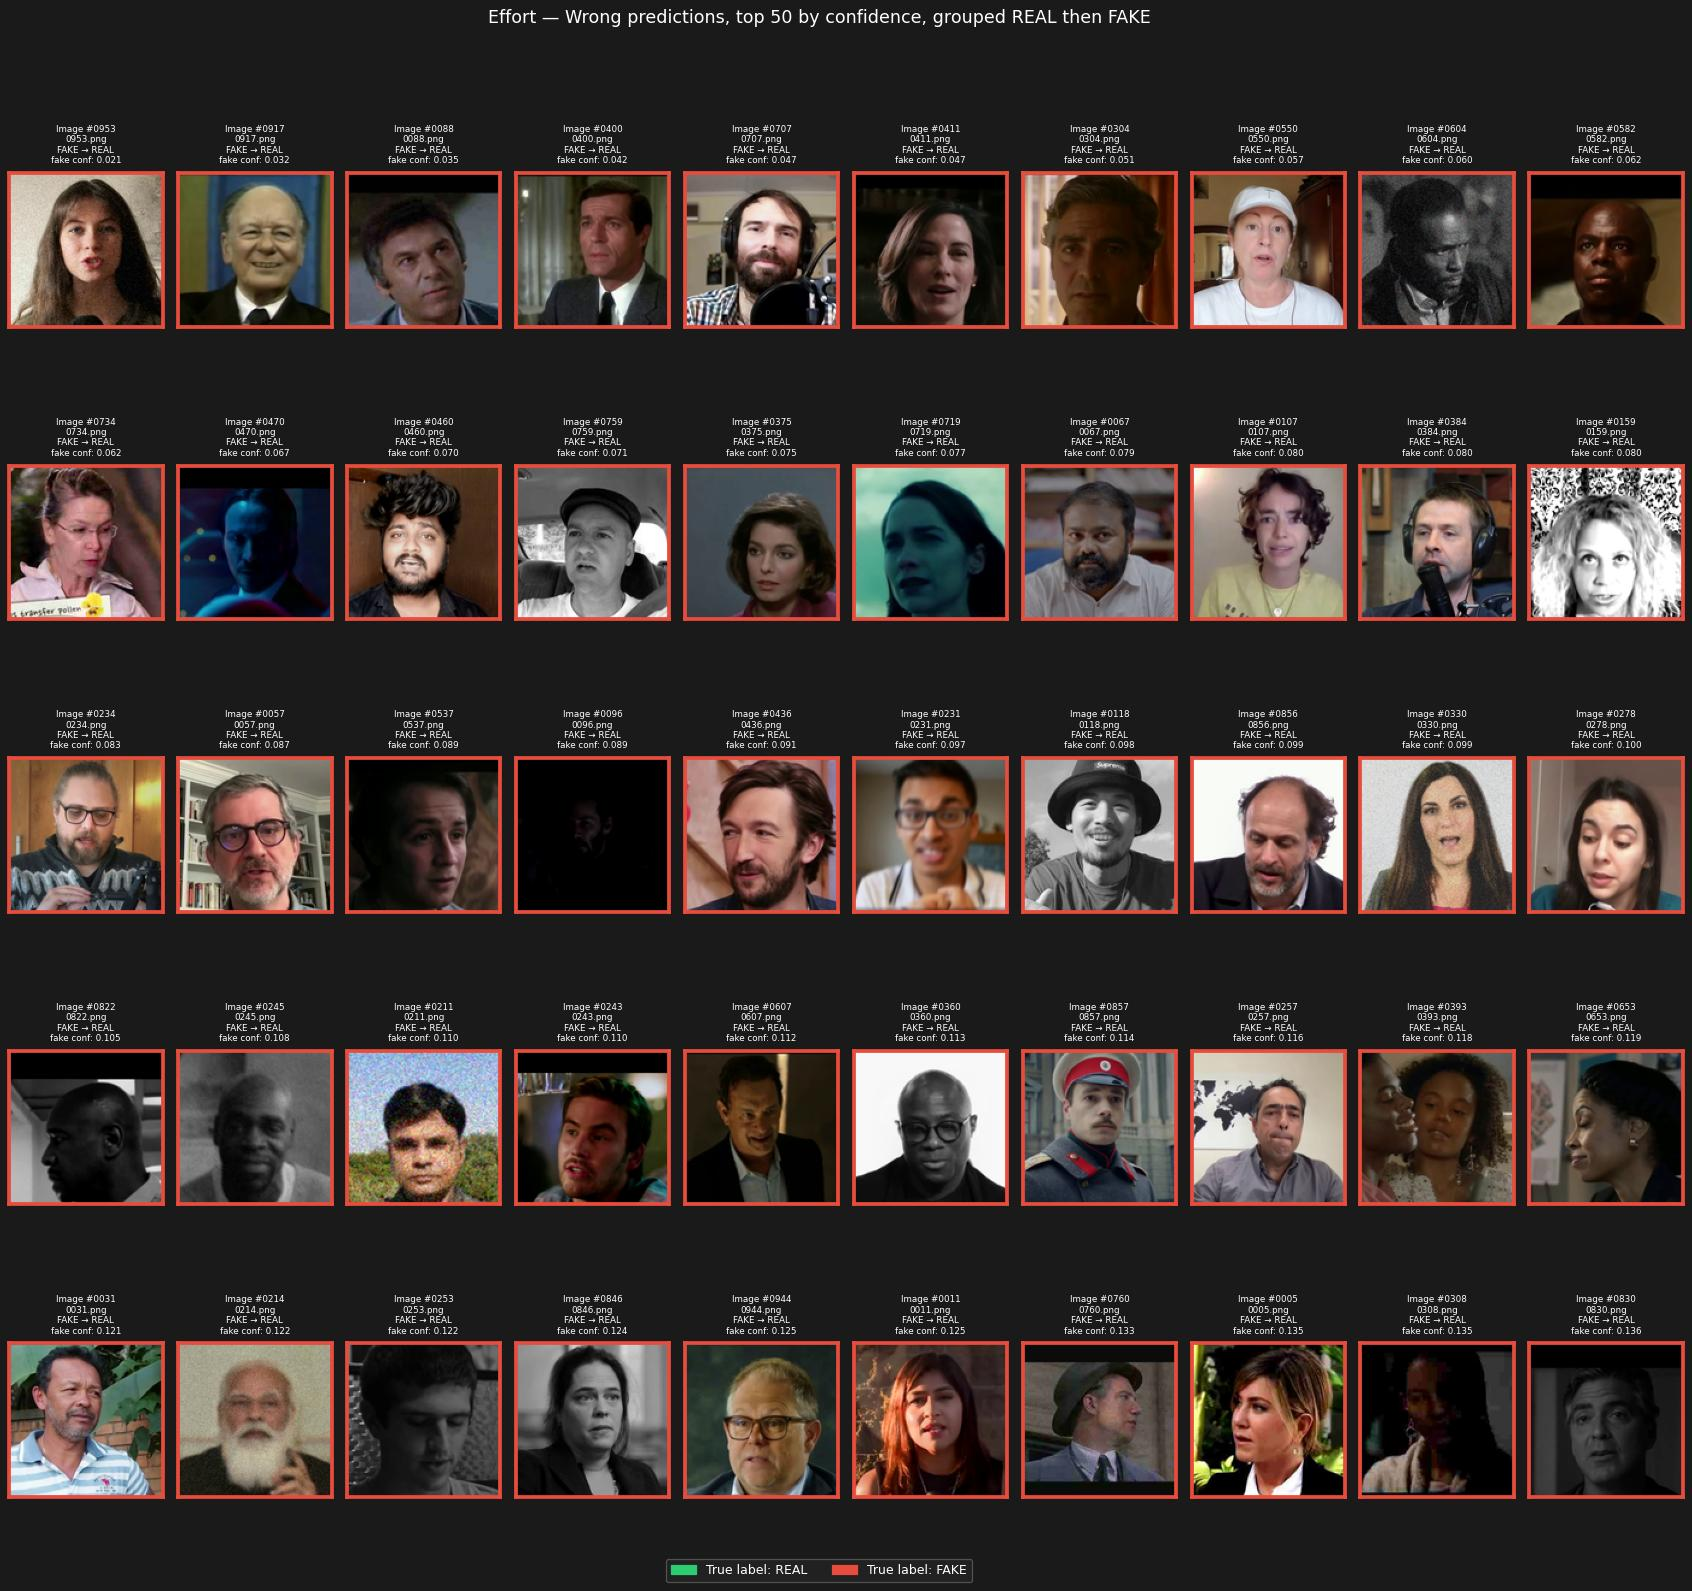

In [ ]:
# ── Badly / Well Detected — Effort top 50 by confidence, grouped REAL / FAKE

%matplotlib inline

import os
import re
import json
import numpy as np
from PIL import Image as PILImage
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import Image, display
from sklearn.metrics import roc_auc_score

THRESHOLD = 0.5

with open(OUT_RESULTS, "r") as f:
    results = json.load(f)

if len(results) == 0:
    raise RuntimeError("Test results file is empty.")

y_true = np.array([int(r["true_label"]) for r in results])
raw_score = np.array([float(r["score"]) for r in results])

auc_direct = roc_auc_score(y_true, raw_score)
print("Using score directly as fake confidence.")
print(f"AUC direct: {auc_direct:.4f}")

# ── Recompute confidence, prediction, and correctness ─────────────────────────
for r in results:
    confidence = float(r["score"])

    r["confidence"] = confidence
    r["pred"] = int(confidence >= THRESHOLD)
    r["correct"] = int(r["pred"]) == int(r["true_label"])

well = [r for r in results if r["correct"]]
badly = [r for r in results if not r["correct"]]

# 1) sort by confidence distance from 0.5
well_sorted = sorted(well, key=lambda x: abs(x["confidence"] - 0.5), reverse=True)
badly_sorted = sorted(badly, key=lambda x: abs(x["confidence"] - 0.5), reverse=True)

# 2) take top 50 first
well_top50 = well_sorted[:50]
badly_top50 = badly_sorted[:50]

# 3) then group REAL first, FAKE second, preserving order inside each label
def group_real_fake(samples):
    real_group = [r for r in samples if int(r["true_label"]) == 0]
    fake_group = [r for r in samples if int(r["true_label"]) == 1]
    return real_group + fake_group

well_sample = group_real_fake(well_top50)
badly_sample = group_real_fake(badly_top50)

print(f"\nCorrect predictions: {len(well)}")
print(f"Wrong predictions:   {len(badly)}")
print(f"Showing correct top50 grouped: {len(well_sample)}")
print(f"Showing wrong top50 grouped:   {len(badly_sample)}")

def label_str(l):
    return "REAL" if int(l) == 0 else "FAKE"

def get_image_number(path):
    fname = os.path.basename(path)
    stem = os.path.splitext(fname)[0]

    if stem.isdigit():
        return stem

    m = re.search(r"\d+", stem)
    return m.group(0) if m else "unknown"

def load_thumb(path, size=128):
    img = PILImage.open(path).convert("RGB")
    w, h = img.size
    side = min(w, h)
    img = img.crop((
        (w - side) // 2,
        (h - side) // 2,
        (w + side) // 2,
        (h + side) // 2
    ))
    return img.resize((size, size), PILImage.LANCZOS)

def make_grid(samples, title, filename, cols=10):
    n = len(samples)
    if n == 0:
        print(f"No samples to show for {filename}")
        return

    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(24, rows * 3.6))
    fig.patch.set_facecolor("#1a1a1a")

    if rows == 1:
        flat_axes = axes.flatten() if hasattr(axes, "flatten") else [axes]
    else:
        flat_axes = axes.flatten()

    for idx, ax in enumerate(flat_axes):
        if idx >= n:
            ax.axis("off")
            continue

        r = samples[idx]

        try:
            ax.imshow(load_thumb(r["path"]))
        except Exception:
            ax.set_facecolor("#333")
            ax.text(
                0.5, 0.5, "error",
                ha="center", va="center",
                color="white", fontsize=7,
                transform=ax.transAxes
            )

        true_color = "#2ecc71" if int(r["true_label"]) == 0 else "#e74c3c"
        for spine in ax.spines.values():
            spine.set_edgecolor(true_color)
            spine.set_linewidth(3)

        ax.set_xticks([])
        ax.set_yticks([])

        fname = os.path.basename(r["path"])
        img_num = get_image_number(r["path"])

        ax.set_title(
            f"Image #{img_num}\n"
            f"{fname}\n"
            f"{label_str(r['true_label'])} → {label_str(r['pred'])}\n"
            f"fake conf: {r['confidence']:.3f}",
            fontsize=7,
            color="white",
            pad=8
        )

    for ax in flat_axes[n:]:
        ax.axis("off")

    real_p = mpatches.Patch(color="#2ecc71", label="True label: REAL")
    fake_p = mpatches.Patch(color="#e74c3c", label="True label: FAKE")
    fig.legend(
        handles=[real_p, fake_p],
        loc="lower center",
        ncol=2,
        fontsize=10,
        framealpha=0.3,
        facecolor="#333",
        labelcolor="white",
        bbox_to_anchor=(0.5, 0.005)
    )

    fig.suptitle(title, fontsize=14, color="white", fontweight="medium")
    plt.subplots_adjust(hspace=0.85, wspace=0.1, top=0.88, bottom=0.06)

    plt.savefig(
        filename,
        dpi=90,
        bbox_inches="tight",
        facecolor=fig.get_facecolor()
    )
    plt.close(fig)

    display(Image(filename))

make_grid(
    well_sample,
    title="Effort — Correct predictions, top 50 by confidence, grouped REAL then FAKE",
    filename="effort_well_detected_grouped.jpg"
)

make_grid(
    badly_sample,
    title="Effort — Wrong predictions, top 50 by confidence, grouped REAL then FAKE",
    filename="effort_badly_detected_grouped.jpg"
)

In [ ]:
import nbformat
NOTEBOOK_PATH = "/content/drive/MyDrive/Capstone_Hripsime/Code Notebooks/Effort F Test.ipynb"

nb = nbformat.read(NOTEBOOK_PATH, as_version=4)

if "widgets" in nb.metadata:
    del nb.metadata["widgets"]

nbformat.write(nb, NOTEBOOK_PATH)

In [ ]:
!pip install nbconvert -q

NOTEBOOK_PATH = "/content/drive/MyDrive/Capstone_Hripsime/Code Notebooks/Effort F Test.ipynb"
OUTPUT_DIR    = "/content/drive/MyDrive/Capstone_Hripsime/Code Notebooks/HTML Notebooks"

!jupyter nbconvert \
    --to html \
    --embed-images \
    --output-dir "{OUTPUT_DIR}" \
    "{NOTEBOOK_PATH}"

print("Done — check your Drive for the .html file")

[NbConvertApp] Converting notebook /content/drive/MyDrive/Capstone_Hripsime/Code Notebooks/Effort F Test.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 5 image(s).
[NbConvertApp] Writing 2402038 bytes to /content/drive/MyDrive/Capstone_Hripsime/Code Notebooks/HTML Notebooks/Effort F Test.html
Done — check your Drive for the .html file
